# Audio Feature Extraction

For this first hands-on session, we are going to investigate the extraction of audio features. This is the first step for designing a classification model (in future hands-on sessions). <br>
As the recording of audio signals using a microphone will also be covered in a future hands-on session, we will start with pre-recorded sounds. They have been placed in the `soundfiles` subdirectory.

To ensure you are catching the content of this notebook, we leave you with a small amount of **code to write**. 

You will find the zones to be briefly filled  with a `### TO COMPLETE` in the cells below.

This first cell imports the required libraries.
We use uv to manage the libraries, some are common ones downloaded while other are custom ones available in `classification/src`.
If that cell doesn't run properly, it probably isn't run with the correct kernel, maybe linked to a wrong uv installation.

In [1]:
import librosa  # For audio signal computations as MFCC
import matplotlib.pyplot as plt
import numpy as np
import sounddevice as sd
import soundfile as sf
from scipy import signal

from classification.datasets import get_train_test, get_cls_from_path
from classification.utils.plots import plot_audio, plot_specgram

import random # Set seed s.t. all students have the same dataset
random.seed(42**67)

We instantiate our dataset through a custom function. The dataset object is defined in ``datasets/__init__.py``.

In [2]:
dataset, _ = get_train_test() # The second return is a test set which will be used later for classification

print("\n".join(dataset.list_classes()))

chainsaw
fireworks
gunshots


You can now select a sound from a given class using ``dataset[class_name, sound_index]``. For example, the third sound of the ``chainsaw`` class is accessed with ``dataset["chainsaw", 2]`` and the following cell plays the sound:

In [3]:
sound = dataset["chainsaw", 2]
x, fs = sf.read(sound)

target_dB = 25
x /= np.linalg.norm(x) * 10 ** (-target_dB / 20)
print(f'Playing "{get_cls_from_path(sound)}"')

# If you have no sound, try to uncomment the following to change audio output
#print(sd.query_devices()) # On my linux computer, the "pipewire" device worked
#y = 9 # Audio output id to use
#sd.default.device = [1, y]

sd.play(x, fs)

Playing "chainsaw"


We now ask you to complete the cells below.

## 1) Resampling and filtering

Most probably, your circuit board will sample the analog audio signal at a frequency $f_s = 11025$ Hz. <br>
However, the audio provided in the dataset are sampled with $f_s = 44100$ Hz, you should thus downsample each audio signal to stay coherent with your real setup. There are 2 solutions:
- Rewrite a new dataset with the downsampled audio signals.
- Downsample each audio which is read.

We provide you with the second one.

***
#### <u> The following derivations are not necessary for the rest of this notebook, but are still provided for the curious students... </u>

Let us consider one original audio signal from the dataset and denote it $x[n]$, for $n=0,\dots,N-1$.

The downsampled signal $y$ can be written as 

$$
    y[m] = w[mM],\quad \text{with}\ w[k] = (h \ast x)[k] = \sum_{n=-\infty}^{\infty} h[n]x[k-n],
$$

where $h$ is a discrete low-pass filter and $M$ is the downsampling factor, here $M=4$. <br>

We can expand both $y$ and $w$ according to their Fourier series (DTFT) $Y$ and $W$, respectively, so that:

$$
    y[m] = \frac{1}{2\pi} \int_0^{2\pi} Y(e^{j\Omega}) e^{jm\Omega} d\Omega \tag{1}
$$
$$
    w[mM] = \frac{1}{2\pi} \int_{0}^{2\pi} W(e^{j\Omega}) e^{jmM\Omega} d\Omega = \frac{1}{2\pi} \sum_{k=0}^{M-1} \int_{2\pi k/M}^{2\pi(k+1)/M} W(e^{j\Omega}) e^{jmM\Omega} d\Omega \tag{2}
    $$

Regarding $w$, applying the change of variable $\Omega \leftarrow \Omega-2\pi k/M$ to each integral of the sum, and changing $k \leftarrow M - k$, we can further write

$$
   \textstyle w[mM] = \frac{1}{2\pi} \int_0^{2\pi/M} \sum_{k=0}^{M-1} W[e^{j(\Omega - 2\pi k/M)}] e^{jmM\Omega} d\Omega.
$$


With a final change of variable $\Omega \leftarrow M\Omega$, we get
$$
    \textstyle w[mM] = \frac{1}{2\pi} \int_0^{2\pi} \frac{1}{M} \sum_{k=0}^{M-1} W[e^{j(\Omega - 2\pi k)/M}] e^{jm\Omega} d\Omega.
$$

And by identifying (1) and (2), this yields:
$$
    Y(e^{j\Omega}) = \frac{1}{M} \sum_{k=0}^{M-1} W[e^{j(\Omega -2\pi k)/M}]
$$

***

In practice, here is the observed phenomenon when downsampling the spectrum above with factor $M=2$.

<center> <img src="figs/downsampling.png" alt=""  width="600" height="300"/> </center>

Playing and showing data for :  gunshots
Downsampling factor:  4


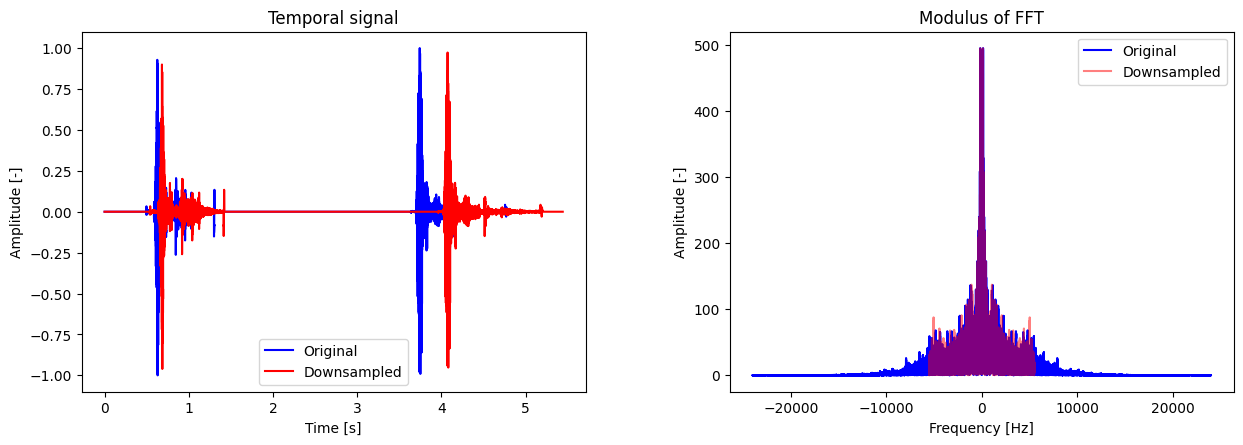

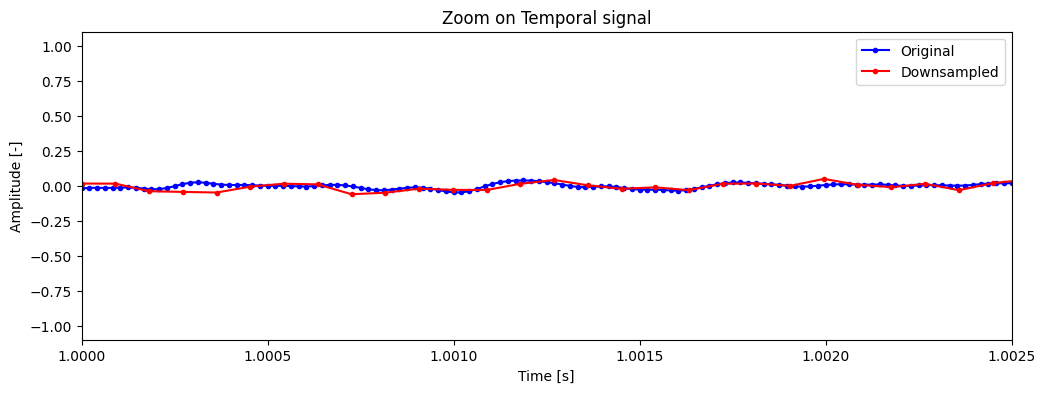

In [4]:
fs_down = 11025  # Target sampling frequency
sound = dataset["gunshots", 16]  # Sound choice

print("Playing and showing data for : ", get_cls_from_path(sound))
x, fs = sf.read(sound)


M = fs // fs_down  # Downsampling factor
print("Downsampling factor: ", M)

### TO COMPLETE
### Downsample x
# x_naive_down = 
# mettre le signal original à la fréquence d'échantillonnage fs_down
x_naive_down = x[::M]



plot_audio(x, x_naive_down, fs, fs_down)  # Function call

Is your downsampling working properly? What can you observe on the spectrum of the downsampled signal? How is this phenomenon named and what is its origin?


In order to avoid it, the original signal should be low-pass filtered prior to downsampling (as presented in the mathematics above).

<span style="color: green;">

Le sous-échantillonnage naïf fonctionne au niveau temporel, mais il ne respecte pas le critère de Nyquist : son spectre présente des composantes repliées dans les basses fréquences. Ce phénomène est appelé **repliement spectral** (*aliasing*). Il est provoqué par les composantes fréquentielles situées au-dessus de la fréquence de Nyquist, qui deviennent indistinguables après la réduction de la fréquence d'échantillonnage.

$$
f_{\mathrm{Nyquist}} = \frac{f_s}{2}
= \frac{11\,025}{2}
= 5\,512{,}5\ \mathrm{Hz}.
$$

Les composantes fréquentielles supérieures à cette limite se replient dans la bande
$[-f_s/2,\,f_s/2]$ et apparaissent alors à tort comme des composantes de plus basse fréquence.

Après filtrage passe-bas, le spectre de `x_filt_down` est nettement plus propre et l'aliasing est fortement réduit. Le filtrage doit donc être effectué avant le sous-échantillonnage.

On remarque également que `fs = 48\,000` Hz et `M = 4`, ce qui donne en réalité une fréquence d'échantillonnage de `12\,000` Hz, et donc une fréquence de Nyquist de `6\,000` Hz. La valeur `fs_down = 11\,025` Hz utilisée dans les graphes n'est donc pas parfaitement cohérente avec ce facteur de sous-échantillonnage.

</span>


<span style="color: gray;">
REPONSE ARTHUR

On observe que pour le signal down-sampling le spectre est sur -Fs/2 et / Fs/2 avec Fs à 11,025 khz. Les hautes fréquences au dessus de Fs/2 se sont
repliées et on les perçoit, à tord, comme des basses fréquences. D'où la nécessité de filtrer au dessus de Fs/2
Ça s'appelle l'aliasing => on observe en orange des fréquences qui n'existent pas dans l'original ou avec une amplitude plus importante car les
hautes fréquences se sont repliées.

En gros, il faut faire un filtre anti-aliasing. Quand on échantillonne il faut respecter Shannon : Fs > 2fmax sinon aliasing : les fréquences au
dessus de fs/2 sont repliées vers les basses fréquences.
Sauf que Fs/2 à 44khz $\neq$ Fs/2 à 11khz donc pour le down sampling il faut faire un filtre passe bas avec fréquence de coupure autour de Fs/2

</span>

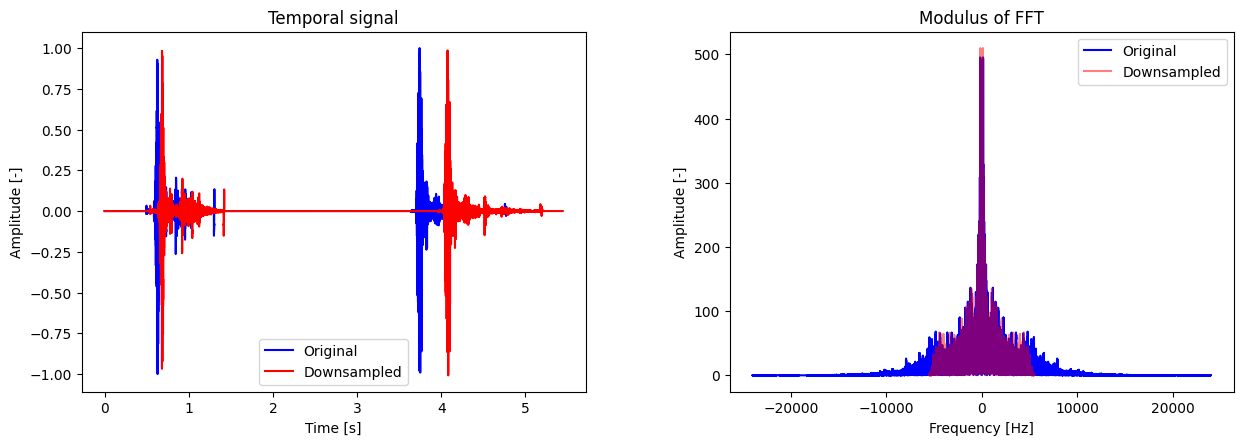

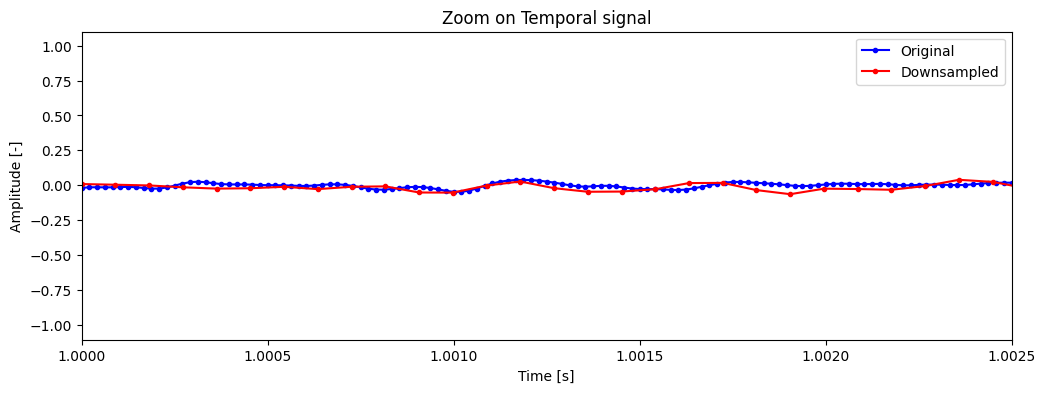

In [5]:
"Low-pass filtering before downsampling"
N = 100  # number of taps
taps = signal.firwin(numtaps=N, cutoff=fs_down / 2, window="hamming", fs=fs)
x_filt = np.convolve(x, taps, mode="full")

### TO COMPLETE
### Downsample ``audio_filt``
x_filt_down = x_filt[::M]


plot_audio(x, x_filt_down, fs, fs_down)

The obtained spectrum of the downsampled signal should not suffer from aliasing anymore. In fact, there is a built-in function in ``scipy.signal`` that performs the downsampling, including a low-pass filter: ``scipy.signal.resample``. Its docstring is:

In [6]:
help(signal.resample)

Help on function resample in module scipy.signal._signaltools:

resample(x, num, t=None, axis=0, window=None, domain='time')
    Resample `x` to `num` samples using Fourier method along the given axis.
    
    The resampled signal starts at the same value as `x` but is sampled
    with a spacing of ``len(x) / num * (spacing of x)``.  Because a
    Fourier method is used, the signal is assumed to be periodic.
    
    Parameters
    ----------
    x : array_like
        The data to be resampled.
    num : int
        The number of samples in the resampled signal.
    t : array_like, optional
        If `t` is given, it is assumed to be the equally spaced sample
        positions associated with the signal data in `x`.
    axis : int, optional
        The axis of `x` that is resampled.  Default is 0.
    window : array_like, callable, string, float, or tuple, optional
        Specifies the window applied to the signal in the Fourier
        domain.  See below for details.
    domain : s

In the following, we use this function.

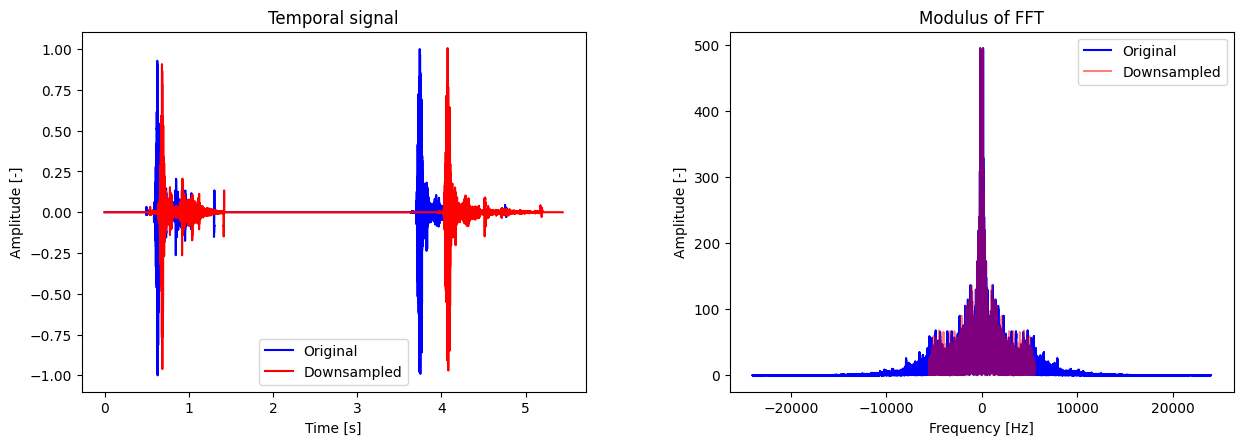

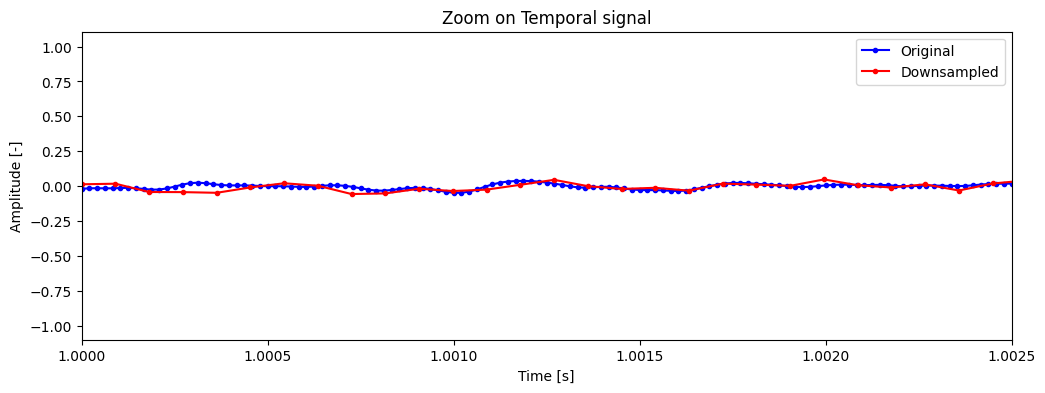

In [7]:
y = signal.resample(x, int(len(x) / M))
L = len(y)

plot_audio(x, y, fs, fs_down)

Can you hear the differences between the downsampled versions of the audio signal and the original one?

<span style="color: green;">

YES

</span>

In [8]:
target_dB = 25
x /= np.linalg.norm(x) * 10 ** (-target_dB / 20)
sd.play(x, fs, blocksize=1024)
#sd.play(x_naive_down, fs_down, blocksize=1024)
#sd.play(x_filt_down, fs_down, blocksize=1024)
#sd.play(y, fs_down, blocksize=1024)

You can also try sounds from different classes by running again the code above and changing the choice of the variable ``sound``. Maybe you will notice there are two *original* and two *downsampled* signals shown. Can you guess why you have two signals? How to deal with this?


<span style="color: green;">

TO RESPONSE

</span>


Now that we are working with sound signals with the same sampling frequency as for the project, we can go on.

## 2) Windowing and spectrogram computation

A very intuitive way to represent an audio signal is with a time-frequency analysis. 
The spectrogram of a signal consists in applying an FFT on successive subpieces of it, and thus obtaining a spectral content evolving with time.

Find an illustration of the idea here below.

<center> <img src="figs/sound2fv.svg" alt="" height="500"/> </center>

Note: You can eventually add a "+1" in the "np.log" to get positive dB. This will look differently.


C:\Users\jeann\AppData\Local\Temp\ipykernel_29132\3163085379.py:38: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(stft2)),


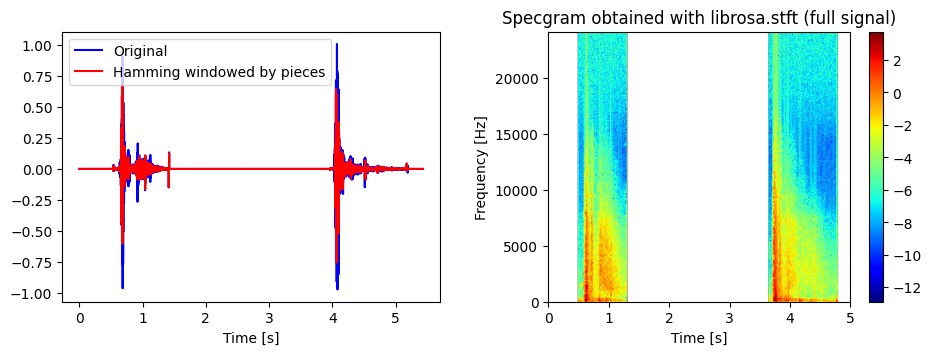

C:\Users\jeann\AppData\Local\Temp\ipykernel_29132\3163085379.py:58: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(stft - stft4[:-1, :])), ax5, title="Difference", tf=len(y) / fs_down


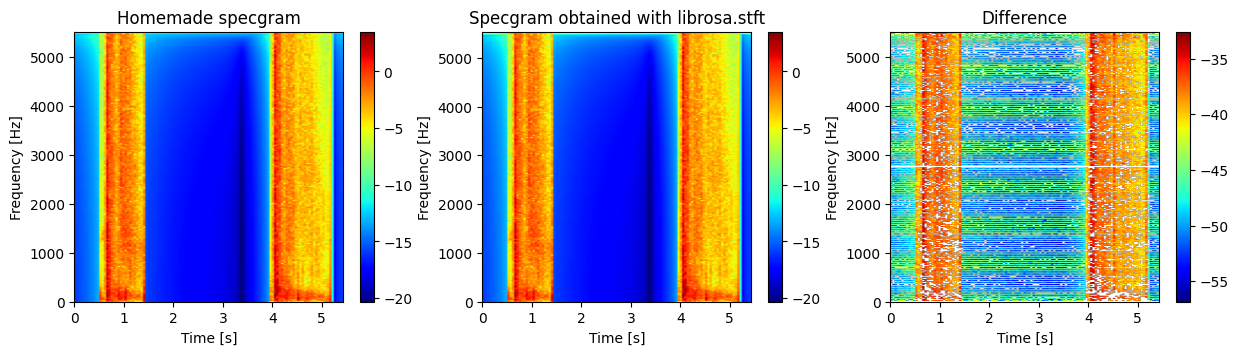

In [9]:
Nft = 512  # Number of samples by FFT

# Homemade computation of stft
"Crop the signal such that its length is a multiple of Nft"
y = y[: L - L % Nft]
L = len(y)
"Reshape the signal with a piece for each row"
audiomat = np.reshape(y, (L // Nft, Nft))
audioham = audiomat * np.hamming(Nft)  # Windowing. Hamming, Hanning, Blackman,..
z = np.reshape(audioham, -1)  # y windowed by pieces
"FFT row by row"
stft = np.fft.fft(audioham, axis=1)
stft = np.abs(
    stft[:, : Nft // 2].T
)  # Taking only positive frequencies and computing the magnitude

"Library Librosa computing stft"
stft2 = librosa.stft(
    x, n_fft=Nft, hop_length=Nft, window="hamm", center="False"
)  # without downsampling the signal
stft4 = np.abs(librosa.stft(z, n_fft=Nft, hop_length=Nft, window="rect", center=False))

print(
    'Note: You can eventually add a "+1" in the "np.log" to get positive dB. This will look differently.'
)

"Plots"
fig = plt.figure(figsize=(9, 3))
ax1 = fig.add_axes([0.0, 0.0, 0.42, 0.9])
ax2 = fig.add_axes([0.54, 0.0, 0.42, 0.9])

ax1.plot(np.arange(L) / fs_down, y, "b", label="Original")
ax1.plot(np.arange(L) / fs_down, z, "r", label="Hamming windowed by pieces")
ax1.set_xlabel("Time [s]")
ax1.legend()

plot_specgram(
    np.log(np.abs(stft2)),
    ax2,
    title="Specgram obtained with librosa.stft (full signal)",
    tf=len(x) / fs,
)
plt.show()

"Comparing the spectrograms"
fig2 = plt.figure(figsize=(12, 3))
ax3 = fig2.add_axes([0.0, 0.0, 0.28, 0.9])
ax4 = fig2.add_axes([0.34, 0.0, 0.28, 0.9])
ax5 = fig2.add_axes([0.68, 0.0, 0.28, 0.9])
plot_specgram(np.log(np.abs(stft)), ax3, title="Homemade specgram", tf=len(y) / fs_down)
plot_specgram(
    np.log(np.abs(stft4)),
    ax4,
    title="Specgram obtained with librosa.stft",
    tf=len(y) / fs_down,
)
plot_specgram(
    np.log(np.abs(stft - stft4[:-1, :])), ax5, title="Difference", tf=len(y) / fs_down
)
plt.show()

What differences can you notice between the upper spectrogram and the two others at the bottom?


<u> Remark:</u> The motivation for having a homemade version of the spectrogram is that in practice these computations will be embedded in the Nucleo board (the transmitter) and coded in C with fixed-point representation. Thus, as your classification model will be trained on feature vectors computed in Python but evaluated on feature vectors computed in C, it's crucial to know what are the exact steps followed for the signal transformation, to have these steps implementable in C, and to ensure they are the same.

<span style="color: green;">
### Comparaison des spectrogrammes

L'image présente trois graphiques côte à côte (de gauche à droite) :

* **Graphique de gauche (« Homemade specgram ») :** Affiche le spectrogramme temps-fréquence calculé avec un algorithme STFT personnalisé.
* **Graphique du milieu (« Specgram obtained with librosa.stft ») :** Affiche le spectrogramme obtenu via la fonction standard de la bibliothèque `librosa.stft`.
* **Graphique de droite (« Difference ») :** Montre la différence d'amplitude (en dB) point par point entre les deux spectrogrammes, sur une échelle de valeurs beaucoup plus faible (environ -52,5 dB à -35,0 dB).

#### Principales observations :
1. **Caractéristiques visuelles quasi identiques :** Les graphiques de gauche (« Homemade ») et du milieu (« librosa ») sont visuellement presque indiscernables dans leurs motifs globaux, leurs structures et leur plage dynamique principale (d'environ -17,5 à +2,5 dB).
2. **Écart résiduel faible :** Le troisième graphique montre qu'il existe de légères différences numériques entre les deux méthodes, situées à un niveau d'amplitude très bas (entre -52,5 dB et -35,0 dB). Cela indique que les deux implémentations produisent un résultat quasi équivalent, avec de très petites variations probablement dues au fenêtrage, au remplissage (*padding*) ou à la précision des calculs en flottants.
</span>


## 3) From Hz to Melspectrogram

Now we have done the major part of the job. But recall that this information will have to be transmitted wirelessly from your circuit board (transmitter) to a base station (receiver). It is thus good practive to try synthetizing a bit the content of this spectrogram. <br>

A popular approach is to transform the frequency axis from Hz to Mel unit. The intuition behind this transformation is that the human ear will more easily distinguish between $100$ and $200$ Hz than between $3000$ and $3100$ Hz. So higher frequencies are more likely to be put together in very fewer coefficients. <br>

This last step will thus consist in replacing each column of the spectrogram ``stft`` with size $N_{FT}$ by a shorter column with size $N_{mel} \ll N_{FT}$. To do so, we will use an Hz to Mel (``Hz2Mel``) transformation matrix provided by ``librosa``, and apply a matrix multiplication for each column.

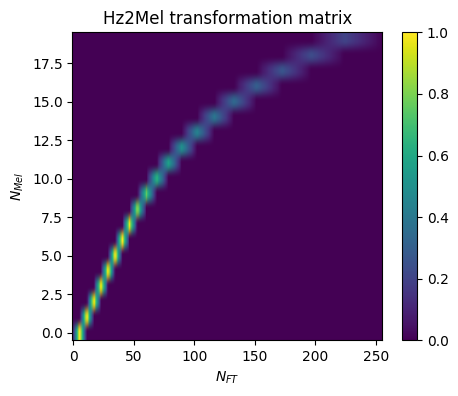

In [10]:
Nmel = 20

"Obtain the Hz2Mel transformation matrix"
mels = librosa.filters.mel(sr=fs_down, n_fft=Nft, n_mels=Nmel)
mels = mels[:, :-1]

### Normalize the mels matrix such that its maximum value is one.
mels = mels / np.max(mels)

"Plot"
plt.figure(figsize=(5, 4))
plt.imshow(mels, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Hz2Mel transformation matrix")
plt.xlabel("$N_{FT}$")
plt.ylabel("$N_{Mel}$")
plt.show()

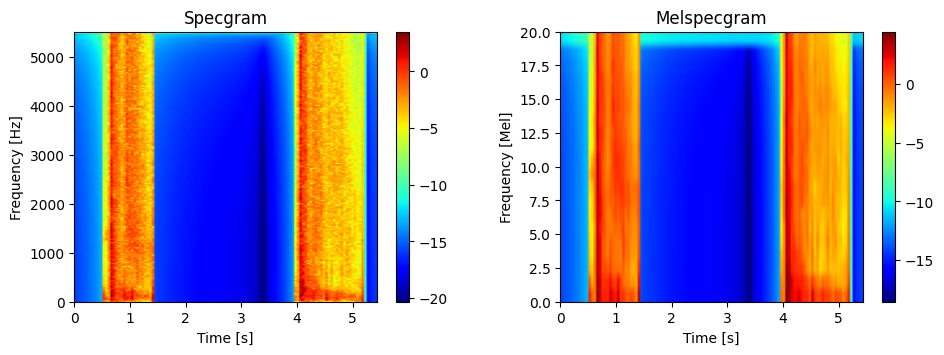

In [11]:
"Melspectrogram computation"
### TO COMPLETE
###  Perform the matrix multiplication between the Hz2Mel matrix and stft.
melspec = mels @ stft

"Plot"
fig = plt.figure(figsize=(9, 3))
ax1 = fig.add_axes([0.0, 0.0, 0.42, 0.9])
ax2 = fig.add_axes([0.54, 0.0, 0.42, 0.9])
plot_specgram(np.log(np.abs(stft)), ax=ax1, title="Specgram", tf=len(y) / fs_down)
plot_specgram(
    np.log(np.abs(melspec)),
    ax=ax2,
    is_mel=True,
    title="Melspecgram",
    tf=len(y) / fs_down,
)
plt.show()

Do these two spectrogram look similar? :) <br> 
What is the gain in the number of coefficients?

<span style="color: green;">

### 1. Ressemblance visuelle

**Oui, les deux représentations sont visuellement très proches dans leur structure globale.**

* **Axe temporel :** Les deux graphiques identifient exactement les mêmes événements sonores au cours du temps (une phase très calme de 0 à 2,5 s, suivie de plusieurs pics d'énergie jusqu'à 5,5 s, interrompus par un creux vers 3,6 s).
* **Axe fréquentiel :** 
  * Le **Spectrogramme classique (`Specgram`)** utilise une échelle linéaire en Hertz (0 à >5000 Hz).
  * Le **Mel-spectrogramme (`Melspecgram`)** applique une échelle psychoacoustique compressée, regroupant l'information sur $N_{mel} = 20$ bandes Mel.

### 2. Calcul du facteur de gain (réduction de dimension)

Le facteur de gain mesure le taux de compression des coefficients fréquentielles à transmettre ou à stocker par trame temporelle.

#### Formule générale :
$$\text{Facteur de gain} = \frac{N_{FT}}{N_{mel}}$$

Où :
* **$N_{FT}$** est le nombre de bins fréquentiels de la STFT initiale ($N_{FT} = \frac{N_{fft}}{2} + 1$).
* **$N_{mel}$** est le nombre de filtres de Mel choisis ($N_{mel} = 20$).


#### Application numérique :
* **$N_{FT} = 257$** (bins de 0 à 256 sur l'axe des fréquences)
* **$N_{mel} = 20$**

$$\text{Facteur de gain} = \frac{257}{20} = \mathbf{12{,}85}$$

$$\text{Taux de compression (\%)} = \left(1 - \frac{N_{mel}}{N_{FT}}\right) \times 100 = \left(1 - \frac{20}{257}\right) \times 100 \approx \mathbf{92{,}21\%}$$


### Conclusion
Le passage en échelle de Mel permet d'obtenir un **facteur de réduction de 12,85** (soit une économie de **92,21 %** du volume de données par trame) tout en conservant l'essentiel de l'information temporelle et fréquentielle utile.

</span>

## 4) Creating black boxes

Now you have seen how to make the computations. <br>
A universal procedure consists in writing functions that will serve as working blocks and hide the computation details.
We can then gradually increase the abstraction. <br>

As any programmer should do, you are strongly encourage to ``fill your functions with a clear and concise docstring``. This will help you later this year when you will want to make improvements to some parts of your code. <br>

**Remark**: In any hands-on session you will work on during this semester, you will be provided with some already implemented code to exploit for processing and visualisation.
The implemented code will sometimes have been written by the teaching staff in the most readable and modular way possible. However, this may happen you want to add some features or simply modify some functions. Feel free to do so. In general, you can modify anything as you wish. Even the Python packages!

In [12]:
def resample(x, M=4):
    """
    Description

    Args:
    ----
      x (type): description
      M (type): description

    Returns:
    -------
      y (type): description

    """
    y = signal.resample(x, int(len(x) / M))
    return y


def specgram(y, Nft=512):
    """
    Description

    Args:
    ----
      y (type): description
      Nft (type): description

    Returns:
    -------
      stft (type): description

    """

    n_frames = len(y) // Nft
    y_truncated = y[: n_frames * Nft]

    stft = np.fft.fft(y_truncated.reshape(-1, Nft) * np.hamming(Nft), axis=1)
    stft = np.abs(stft[:, : Nft // 2].T)

    return stft


def melspecgram(x, Nmel=20, Nft=512, fs=44100, fs_down=11025):
    """
    Description

    Args:
    ----
      x (type): description
      Nmel (type): description
      Nft (type): description
      fs (type): description
      fs_down (type): description

    Returns:
    -------
      melspec (type): description

    """
    ### TO COMPLETE, using the functions resample() and specgram() defined above

    M = fs / fs_down
    y = resample(x, M=M)

    stft = specgram(y, Nft=Nft)

    mels = librosa.filters.mel(sr=fs_down, n_fft=Nft, n_mels=Nmel)
    mels = mels[:, : Nft // 2]

    melspec = mels @ stft

    return melspec

## 5) Show us your skills
You are now encouraged to apply the functions you created above to sounds from the 3 classes. Observe their spectrograms and comment. Is it easy to differentiate sounds from the classes you chose?

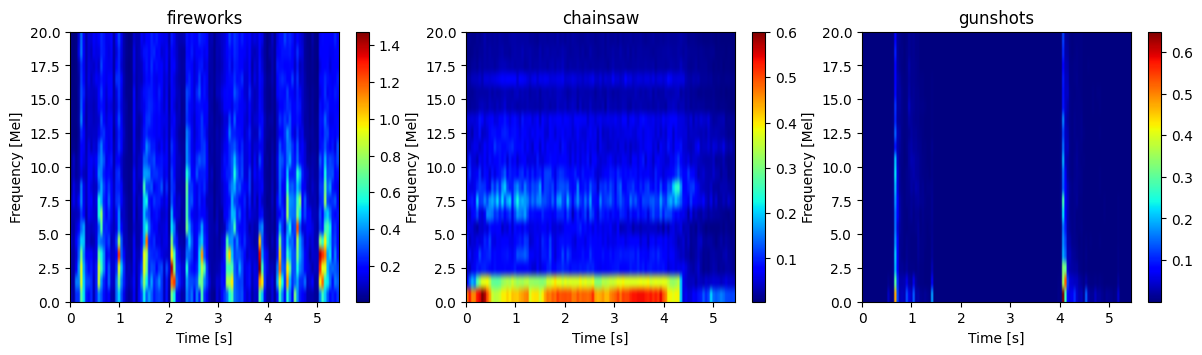

In [13]:
### TO COMPLETE
### Choose 3 sounds from different classes to observe how their mel spectrograms differ
sound1 = dataset["fireworks", 10]
sound2 = dataset["chainsaw", 15]
sound3 = dataset["gunshots", 16]

"Compute the melspecgrams"
x1, _ = sf.read(sound1)
x2, _ = sf.read(sound2)
x3, _ = sf.read(sound3)
melspec1 = melspecgram(x1)
melspec2 = melspecgram(x2)
melspec3 = melspecgram(x3)

"Plot"
fig = plt.figure(figsize=(12, 3))
ax1 = fig.add_axes([0.0, 0.0, 0.28, 0.9])
ax2 = fig.add_axes([0.33, 0.0, 0.28, 0.9])
ax3 = fig.add_axes([0.66, 0.0, 0.28, 0.9])
plot_specgram(
    melspec1, ax=ax1, is_mel=True, title=get_cls_from_path(sound1), tf=len(y) / fs_down
)
plot_specgram(
    melspec2, ax=ax2, is_mel=True, title=get_cls_from_path(sound2), tf=len(y) / fs_down
)
plot_specgram(
    melspec3, ax=ax3, is_mel=True, title=get_cls_from_path(sound3), tf=len(y) / fs_down
)
plt.show()

### Question:
Briefly comment what is intuitive for you in the content of these 3 spectrograms respectively with the corresponding classes.
How can you differentiate them?

<span style="color: green;">


### Analyse et comparaison des 3 spectrogrammes de Mel

L'analyse spectrale permet de différencier clairement les trois classes d'événements acoustiques selon la distribution de leur énergie dans le temps et en fréquence :

#### 1. Feux d'artifice (*Fireworks*)
On observe plusieurs lignes verticales très fines et espacées au cours du temps (notamment vers $1{,}5\text{ s}$, $2{,}3\text{ s}$, $3\text{ s}$, $4\text{ s}$, $5\text{ s}$). Cela correspond à une succession d'explosions brèves et répétées (détonations d'artifices). Chaque impact libère de l'énergie sur une large plage de fréquences (du grave au sub-aigu) sur un temps très court.

#### 2. Tronçonneuse (*Chainsaw*)
Contrairement aux deux autres, l'énergie est continue et concentrée dans les basses fréquences (bandes Mel 0 à 5), avec deux phases d'activation intense (de $0{,}5$ à $1{,}5\text{ s}$ et de $3{,}5$ à $5\text{ s}$). Cela reflète le fonctionnement continu d'un moteur à combustion/mécanique. Les vibrations du moteur génèrent un bruit de fond constant et riche en graves, alternant entre des phases d'accélération (régime moteur élevé) et d'inactivité relative.


#### 3. Coups de feu (*Gunshots*)
Le spectrogramme est très "vide" la majorité du temps, interrompu par des pics très localisés, brusques et intenses (notamment vers $2{,}5\text{ s}$ et $4\text{ s}$). Un coup de feu est un signal impulsif unique très bref mais extrêmement énergétique (ce qui se traduit par une amplitude maximale plus élevée sur la barre de couleur, atteignant $> 0{,}6$).


### Résumé des critères de différenciation

| Classe | Signature temporelle | Distribution fréquentielle | Niveau d'amplitude relatif |
| :--- | :--- | :--- | :--- |
| **Fireworks** | Impulsions multiples et régulières | Étendue du grave au médium/aigu | Modéré ($\approx 0{,}20$) |
| **Chainsaw** | Bruit continu avec phases d'accélération | Fortement concentrée dans les graves ($0-5\text{ Mel}$) | Moyen à fort ($\approx 0{,}35$) |
| **Gunshots** | Impulsions très brèves et isolées | Impulsion large bande brutale | Très fort ($> 0{,}60$) |
</span>